In [25]:
import pandas as pd
import numpy as np 
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [26]:
df=pd.read_csv("vehicles.csv")

In [27]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [28]:
df.tail()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


In [29]:
df.sample(5)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
202700,7305419238,https://grandrapids.craigslist.org/cto/d/wyomi...,grand rapids,https://grandrapids.craigslist.org,10500,2013.0,bmw,x1 awd 4dr xdrive28i,excellent,4 cylinders,...,NaN,hatchback,orange,https://images.craigslist.org/00707_8QHESUu3yg...,-Comes with set of winter tires -New battery -...,NaN,mi,42.897700,-85.718600,2021-04-11T20:04:38-0400
362055,7309481422,https://tricities.craigslist.org/ctd/d/ford-15...,tri-cities,https://tricities.craigslist.org,0,2014.0,ford,f-150,NaN,8 cylinders,...,full-size,pickup,silver,https://images.craigslist.org/00606_fV47GXq8bg...,2014 Ford F-150 XLT Pickup Truck We Finance Ca...,NaN,tn,NaN,NaN,2021-04-19T16:54:04-0400
422360,7316327834,https://milwaukee.craigslist.org/ctd/d/milwauk...,milwaukee,https://milwaukee.craigslist.org,3999,2004.0,chevrolet,trailblazer ext,like new,8 cylinders,...,NaN,SUV,NaN,https://images.craigslist.org/00F0F_9Nh8T06q61...,2004 CHEVROLET TRAILBLAZER EXT 4WD SPORT LUXUR...,NaN,wi,43.118800,-87.947800,2021-05-03T13:17:10-0500
233722,7310886010,https://charlotte.craigslist.org/ctd/d/salem-2...,charlotte,https://charlotte.craigslist.org,44200,2017.0,ford,NaN,NaN,8 cylinders,...,compact,other,NaN,https://images.craigslist.org/00N0N_jFk9UAKjJi...,2017 *** FORD Shelby GT350 Base*** ...,NaN,nc,44.927304,-123.030322,2021-04-22T12:21:42-0400
71184,7307871250,https://yubasutter.craigslist.org/ctd/d/yuba-c...,yuba-sutter,https://yubasutter.craigslist.org,7999,2005.0,ford,mustang deluxe,excellent,6 cylinders,...,NaN,coupe,NaN,https://images.craigslist.org/00e0e_3SoPAuGXdg...,"2005 Ford Mustang Deluxe158,332 mi. - - 2D Co...",NaN,ca,39.123441,-121.611440,2021-04-16T12:08:05-0700


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [31]:
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [32]:
df.isnull()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,False,False,False,False,False,True,True,True,True,True,...,True,True,True,True,True,True,False,True,True,True
1,False,False,False,False,False,True,True,True,True,True,...,True,True,True,True,True,True,False,True,True,True
2,False,False,False,False,False,True,True,True,True,True,...,True,True,True,True,True,True,False,True,True,True
3,False,False,False,False,False,True,True,True,True,True,...,True,True,True,True,True,True,False,True,True,True
4,False,False,False,False,False,True,True,True,True,True,...,True,True,True,True,True,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,False,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,True,False,False,False,False
426876,False,False,False,False,False,False,False,False,False,True,...,True,False,False,False,False,True,False,False,False,False
426877,False,False,False,False,False,False,False,False,False,True,...,True,False,False,False,False,True,False,False,False,False
426878,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False


In [33]:
df.isnull().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:

categorical_columns=df.columns[df.dtypes=="object"]
numerical_columns=df.columns[df.dtypes!="object"]


In [36]:
df[categorical_columns].describe()

,url,region,region_url,manufacturer,model,condition,cylinders,fuel,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,state,posting_date
count,426880,426880,426880,409234,421603,252776,249202,423867,418638,424324,265838,296313,120519,334022,296677,426812,426810,426880,426812
unique,426880,404,413,42,29667,6,8,5,6,3,118264,3,4,13,12,241899,360911,51,381536
top,https://prescott.craigslist.org/cto/d/prescott...,columbus,https://spokane.craigslist.org,ford,f-150,good,6 cylinders,gas,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,https://images.craigslist.org/00N0N_1xMPvfxRAI...,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,ca,2021-04-23T22:13:05-0400
freq,1,3608,2988,70985,8009,121456,94169,356209,405117,336524,261,131904,63465,87056,79285,7357,231,50614,12


In [37]:

df[categorical_columns]

,url,region,region_url,manufacturer,model,condition,cylinders,fuel,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,state,posting_date
0,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN
1,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,nissan,maxima s sedan 4d,good,6 cylinders,gas,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,wy,2021-04-04T03:21:31-0600
426876,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,wy,2021-04-04T03:21:29-0600
426877,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,cadillac,xt4 sport suv 4d,good,NaN,diesel,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,wy,2021-04-04T03:21:17-0600
426878,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,lexus,es 350 sedan 4d,good,6 cylinders,gas,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,wy,2021-04-04T03:21:11-0600


In [38]:
for col in df.columns:
    print(col , ":" , df[col].unique())

id : [7222695916 7218891961 7221797935 ... 7301591147 7301591140 7301591129]
url : ['https://prescott.craigslist.org/cto/d/prescott-2010-ford-ranger/7222695916.html'
 'https://fayar.craigslist.org/ctd/d/bentonville-2017-hyundai-elantra-se/7218891961.html'
 'https://keys.craigslist.org/cto/d/summerland-key-2005-excursion/7221797935.html'
 ...
 'https://wyoming.craigslist.org/ctd/d/atlanta-2020-caddy-cadillac-xt4-sport/7301591147.html'
 'https://wyoming.craigslist.org/ctd/d/atlanta-2018-lexus-es-es-350-sedan-4d/7301591140.html'
 'https://wyoming.craigslist.org/ctd/d/atlanta-2019-bmw-series-430i-gran-coupe/7301591129.html']
region : ['prescott' 'fayetteville' 'florida keys' 'worcester / central MA'
 'greensboro' 'hudson valley' 'medford-ashland' 'erie' 'el paso'
 'bellingham' 'skagit / island / SJI' 'la crosse' 'auburn' 'birmingham'
 'dothan' 'florence / muscle shoals' 'gadsden-anniston'
 'huntsville / decatur' 'mobile' 'montgomery' 'tuscaloosa'
 'anchorage / mat-su' 'fairbanks' 'kenai pe

In [39]:
df['posting_date'] = pd.to_datetime(df['posting_date'], utc=True)
df['posting_year'] = df['posting_date'].dt.year
df['posting_month'] = df['posting_date'].dt.month
df['posting_day_of_week'] = df['posting_date'].dt.dayofweek
df['posting_hour'] = df['posting_date'].dt.hour
df.drop(columns=['posting_date'], inplace=True) 

In [40]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


eda_df = df[(df['price'] >= 500) & (df['price'] <= 100000) & 
            (df['odometer'] <= 300000) & (df['year'] >= 1990)].copy()
#only for drawing

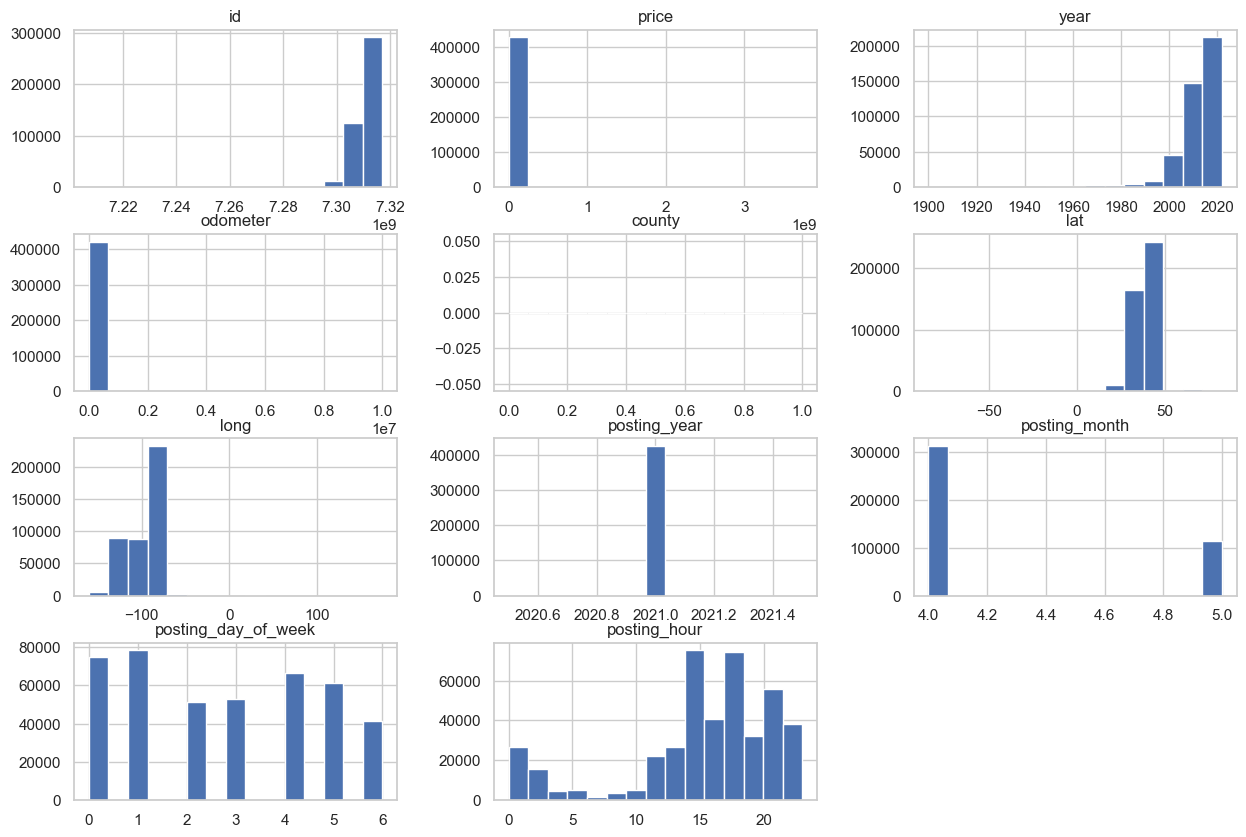

In [41]:
df.hist(bins=15,figsize=(15,10))
plt.show()

In [42]:
top10cars=df["manufacturer"].value_counts().sort_values(ascending=False)[:10]
top10cars

manufacturer
ford         70985
chevrolet    55064
toyota       34202
honda        21269
nissan       19067
jeep         19014
ram          18342
gmc          16785
bmw          14699
dodge        13707
Name: count, dtype: int64

<Axes: xlabel='manufacturer', ylabel='count'>

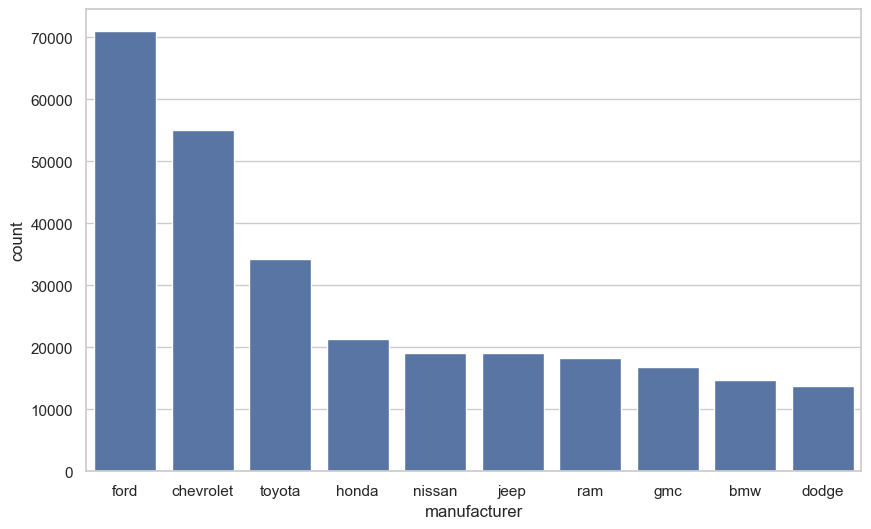

In [43]:
sns.barplot( top10cars )

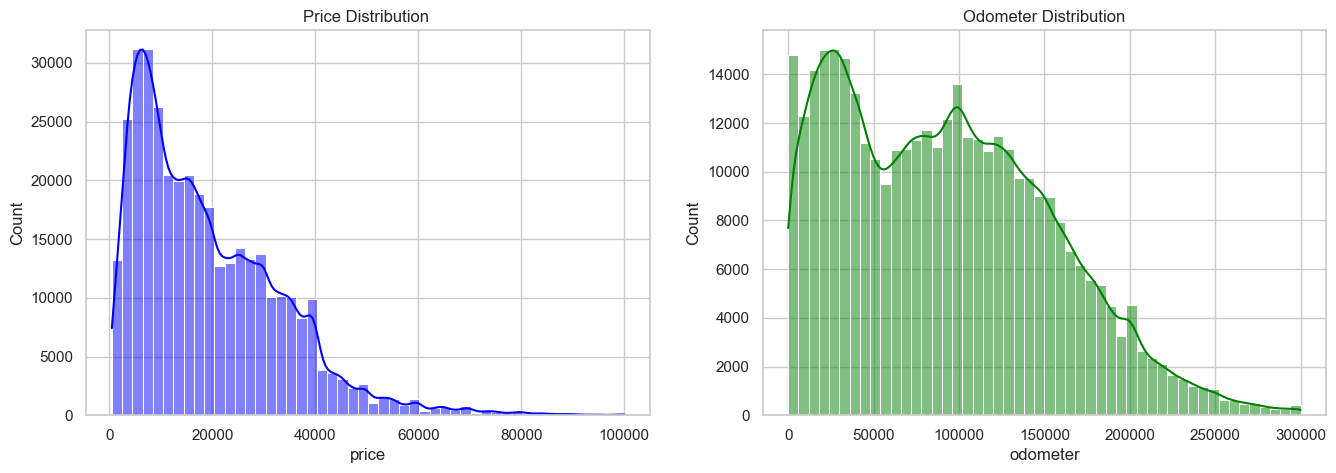

In [44]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


sns.histplot(eda_df['price'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Price Distribution ')

sns.histplot(eda_df['odometer'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Odometer Distribution')
plt.show()

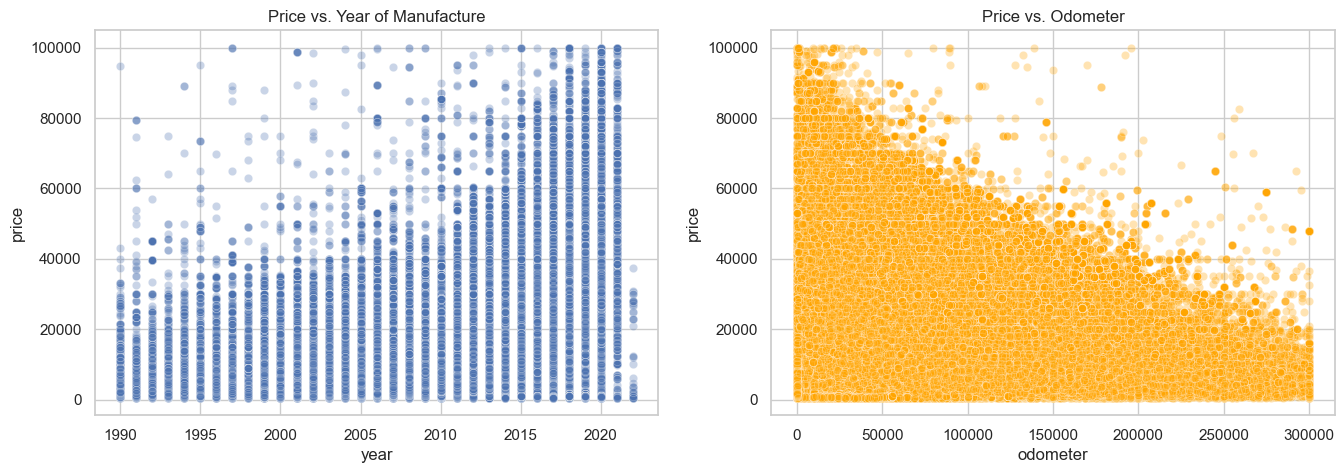

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


sns.scatterplot(x='year', y='price', data=eda_df, alpha=0.3, ax=axes[0])
axes[0].set_title('Price vs. Year of Manufacture')


sns.scatterplot(x='odometer', y='price', data=eda_df, alpha=0.3, ax=axes[1], color='orange')
axes[1].set_title('Price vs. Odometer')
plt.show()

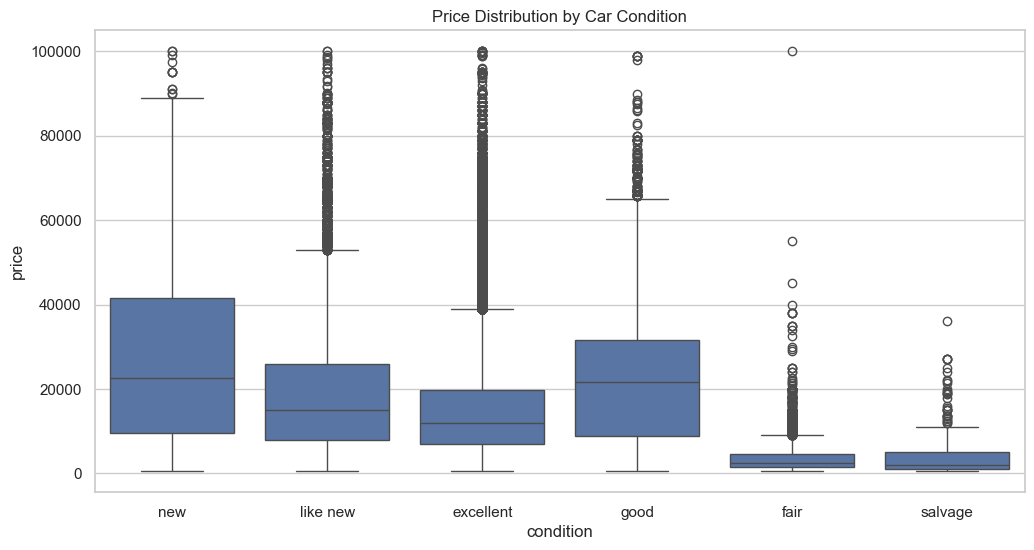

In [46]:

plt.figure(figsize=(12, 6))

sns.boxplot(x='condition', y='price', data=eda_df, order=['new', 'like new', 'excellent', 'good', 'fair', 'salvage'])
plt.title('Price Distribution by Car Condition')
plt.show()

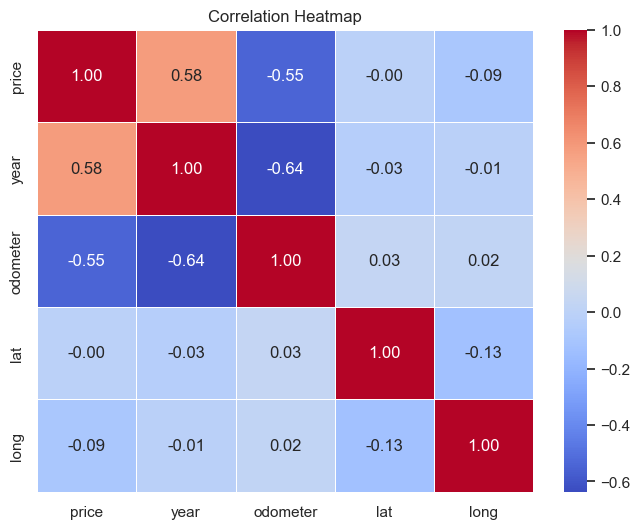

In [47]:
plt.figure(figsize=(8, 6))

numerical_cols = ['price', 'year', 'odometer', 'lat' , 'long' ]
corr_matrix = eda_df[numerical_cols].corr()


sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

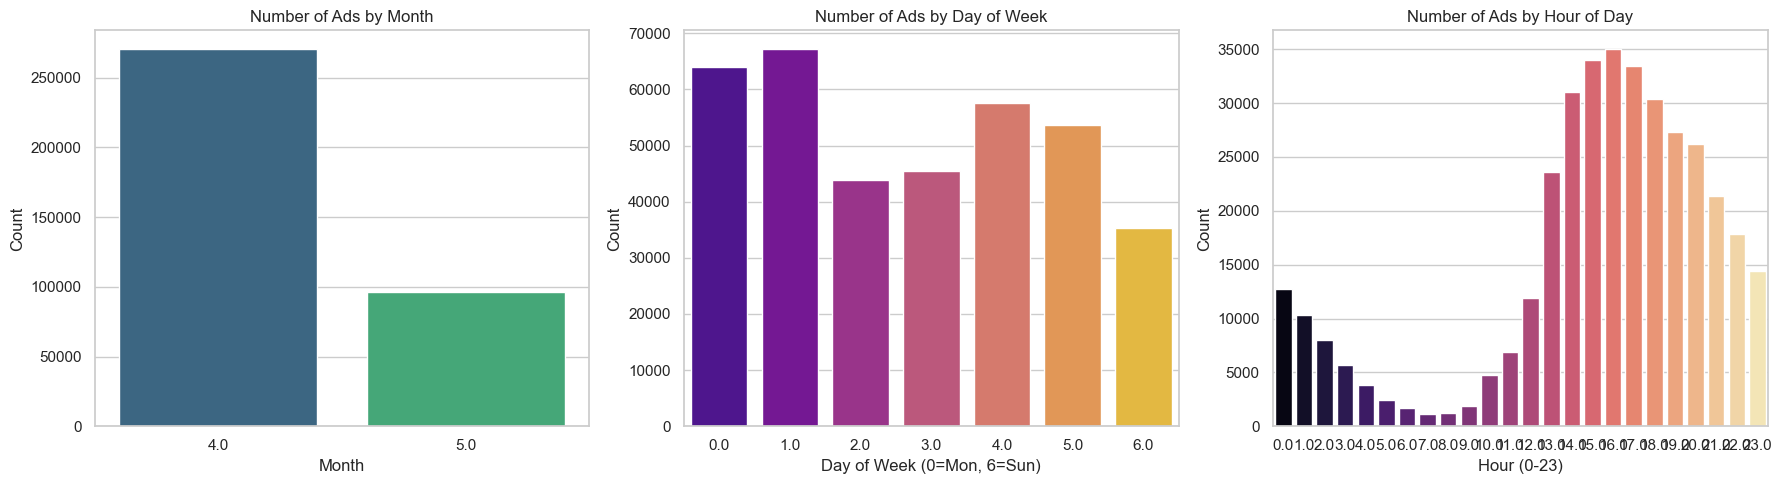

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.countplot(data=eda_df, x='posting_month', ax=axes[0], palette='viridis')
axes[0].set_title('Number of Ads by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')


sns.countplot(data=eda_df, x='posting_day_of_week', ax=axes[1], palette='plasma')
axes[1].set_title('Number of Ads by Day of Week')
axes[1].set_xlabel('Day of Week (0=Mon, 6=Sun)')
axes[1].set_ylabel('Count')

sns.countplot(data=eda_df, x='posting_hour', ax=axes[2], palette='magma')
axes[2].set_title('Number of Ads by Hour of Day')
axes[2].set_xlabel('Hour (0-23)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

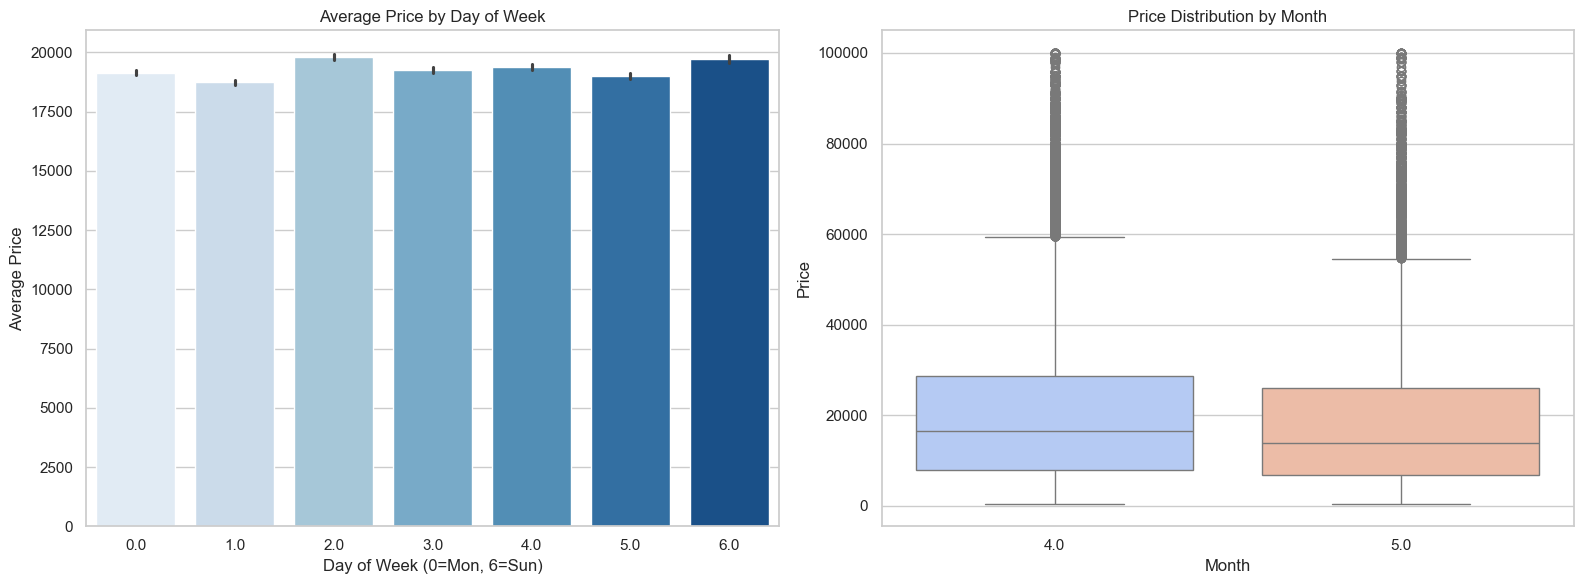

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.barplot(data=eda_df, x='posting_day_of_week', y='price', ax=axes[0], palette='Blues')
axes[0].set_title('Average Price by Day of Week')
axes[0].set_xlabel('Day of Week (0=Mon, 6=Sun)')
axes[0].set_ylabel('Average Price')

sns.boxplot(data=eda_df, x='posting_month', y='price', ax=axes[1], palette='coolwarm')
axes[1].set_title('Price Distribution by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

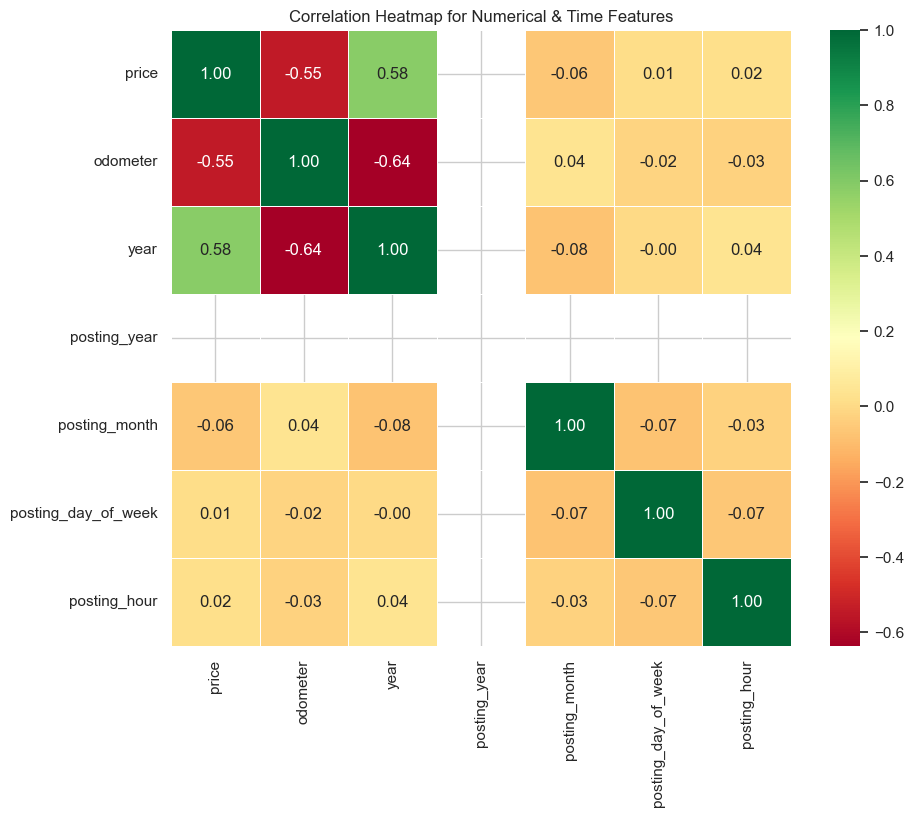

In [ ]:
plt.figure(figsize=(10, 8))


numeric_cols = ['price', 'odometer', 'year', 'posting_year', 'posting_month', 'posting_day_of_week', 'posting_hour']

# حساب مصفوفة الارتباط
corr_matrix = eda_df[numeric_cols].corr()


sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap for Numerical & Time Features')

plt.show()

# 📊 Executive Summary: Exploratory Data Analysis (EDA)

---

## 💡 I. Key Insights (Data-Driven Observations)

### 🚗 Brand Dominance & Market Preferences
* **Top Brands:** **Ford** and **Chevrolet** heavily dominate the ad volume on the platform, followed by **Toyota** and **Honda**. 
* **Takeaway:** The market strongly leans towards American vehicles for utility and heavy-duty use, and Japanese vehicles for reliability.

### 🎯 Target Market Profile
* **Price Range:** The vast majority of vehicles are listed between **$5,000 and $30,000**.
* **Usage (Mileage):** The odometer distribution shows a massive concentration of cars with **100,000 to 150,000 miles**.
* **Takeaway:** The platform primarily serves the *economical and daily-commuter used car* segment, rather than the luxury or nearly-new vehicle market.

### 🕒 User Activity Trends (Time-Based)
* **Weekly Volume:** Ad posting peaks at the beginning of the week (Mondays and Tuesdays) and gradually declines toward the weekend.
* **Daily Volume:** Activity peaks during standard working hours (**10:00 AM to 4:00 PM**) and drops significantly late at night.

### 💰 Primary Price Drivers
Based on the correlation matrix, the main factors dictating vehicle price are:
1. **Manufacturing Year:** Strong positive correlation (0.58).
2. **Odometer Reading:** Strong negative correlation (-0.55).
* *Note:* The time or day the ad is posted has virtually **zero impact** on the listed price.

---

## 🚀 II. Business Recommendations (Actionable Strategies)

> **1. Optimize Marketing & Engagement**
> Since users are most active between 10 AM and 4 PM early in the week, the marketing team should schedule push notifications, email campaigns, and digital ads to hit during these peak windows to maximize ROI. Ad spend should be minimized during late-night hours.

> **2. Streamline Operations & Support**
> Allocate more customer support agents and ad-moderation resources during the identified peak hours (mid-day, Monday/Tuesday). This ensures faster ad approvals, quicker response times, and an overall better seller experience.

> **3. Develop a "Smart Pricing" Product Feature**
> Because year and odometer are the definitive price drivers, the engineering team can build an automated **Smart Pricing Tool**. When a user inputs their car's year and mileage, the platform can automatically recommend a competitive price range, helping sellers close deals faster and improving user retention.

> **4. Guide Inventory Sourcing**
> If the business operates on a "buy-and-resell" model, capital allocation should focus heavily on Ford, Chevrolet, and Toyota vehicles within the **$10k–$30k** price bracket. This specific segment represents the highest liquidity and the fastest inventory turnover rate on the platform.